In [1]:
import pandas as pd
import numpy as np

In [14]:
data = pd.read_csv("bank_transactions.csv")
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10-01-1994,F,JAMSHEDPUR,17819.05,02-08-2016,143207,25.0
1,T2,C2142763,04-04-1957,M,JHAJJAR,2270.69,02-08-2016,141858,27999.0
2,T3,C4417068,26-11-1996,F,MUMBAI,17874.44,02-08-2016,142712,459.0
3,T4,C5342380,14-09-1973,F,MUMBAI,866503.21,02-08-2016,142714,2060.0
4,T5,C9031234,24-03-1988,F,NAVI MUMBAI,6714.43,02-08-2016,181156,1762.5


In [15]:
data = data.drop(columns=['TransactionID', 'CustomerID'])

In [18]:
data.head()

,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,10-01-1994,F,JAMSHEDPUR,17819.05,02-08-2016,143207,25.0
1,04-04-1957,M,JHAJJAR,2270.69,02-08-2016,141858,27999.0
2,26-11-1996,F,MUMBAI,17874.44,02-08-2016,142712,459.0
3,14-09-1973,F,MUMBAI,866503.21,02-08-2016,142714,2060.0
4,24-03-1988,F,NAVI MUMBAI,6714.43,02-08-2016,181156,1762.5


In [25]:
data["CustomerDOB"].isnull().sum()

np.int64(72)

In [26]:
data['TransactionTime'] = pd.to_datetime(data['TransactionTime'].astype(str), format='%H%M%S')

In [29]:
data.head()

,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,10-01-1994,F,JAMSHEDPUR,17819.05,02-08-2016,1900-01-01 14:32:07,25.0
1,04-04-1957,M,JHAJJAR,2270.69,02-08-2016,1900-01-01 14:18:58,27999.0
2,26-11-1996,F,MUMBAI,17874.44,02-08-2016,1900-01-01 14:27:12,459.0
3,14-09-1973,F,MUMBAI,866503.21,02-08-2016,1900-01-01 14:27:14,2060.0
4,24-03-1988,F,NAVI MUMBAI,6714.43,02-08-2016,1900-01-01 18:11:56,1762.5


In [36]:
data['CustomerDOB'] = pd.to_datetime(data['CustomerDOB'], format='%d-%m-%Y', errors='coerce')

In [79]:
data['Age'] = (pd.Timestamp.today() - pd.to_datetime(data['CustomerDOB'], format='%d-%m-%Y')).dt.days // 365

KeyError: 'CustomerDOB'

In [51]:
data.head()

,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,17819.05,02-08-2016,14:32:07,25.0,32
1,M,JHAJJAR,2270.69,02-08-2016,14:18:58,27999.0,69
2,F,MUMBAI,17874.44,02-08-2016,14:27:12,459.0,29
3,F,MUMBAI,866503.21,02-08-2016,14:27:14,2060.0,52
4,F,NAVI MUMBAI,6714.43,02-08-2016,18:11:56,1762.5,38


In [48]:
data['Age'] = data['Age'].fillna(0).astype(int)

In [ ]:
data['TransactionTime'] = pd.to_datetime(data['TransactionTime']).dt.time


In [61]:
data.head()


,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Day,Month
0,F,JAMSHEDPUR,17819.05,02-08-2016,14:32:07,25.0,32,2,8
1,M,JHAJJAR,2270.69,02-08-2016,14:18:58,27999.0,69,2,8
2,F,MUMBAI,17874.44,02-08-2016,14:27:12,459.0,29,2,8
3,F,MUMBAI,866503.21,02-08-2016,14:27:14,2060.0,52,2,8
4,F,NAVI MUMBAI,6714.43,02-08-2016,18:11:56,1762.5,38,2,8


In [60]:
data['Day'] = pd.to_datetime(data['TransactionDate'], format='%d-%m-%Y').dt.day
data['Month'] = pd.to_datetime(data['TransactionDate'], format='%d-%m-%Y').dt.month


In [62]:
data['Year'] = pd.to_datetime(data['TransactionDate'], format='%d-%m-%Y').dt.year

In [75]:
data.head()

,CustGender,CustLocation,CustAccountBalance,TransactionAmount (INR),Age,Day,Month,Hour,Minute
0,F,JAMSHEDPUR,17819.05,25.0,32,2,8,14,32
1,M,JHAJJAR,2270.69,27999.0,69,2,8,14,18
2,F,MUMBAI,17874.44,459.0,29,2,8,14,27
3,F,MUMBAI,866503.21,2060.0,52,2,8,14,27
4,F,NAVI MUMBAI,6714.43,1762.5,38,2,8,18,11


In [70]:
data['TransactionTime'] = pd.to_datetime(data['TransactionTime'], format='%H:%M:%S')


data['Hour'] = data['TransactionTime'].dt.hour
data['Minute'] = data['TransactionTime'].dt.minute

In [72]:
data = data.drop(columns=['TransactionDate','Year'])

In [74]:
del data['TransactionTime']

In [78]:
data['CustLocation'].value_counts()

CustLocation
MUMBAI                          1994
NEW DELHI                       1628
BANGALORE                       1575
DELHI                           1371
GURGAON                         1363
                                ... 
CUDDALORE(DT)                      1
ALAM ROZA AHMEDABAD                1
RLY STN NAVI MUMBAI                1
KUVA WALI GALI GREATER NOIDA       1
MODEL SCHOOL HYDERABAD             1
Name: count, Length: 1781, dtype: int64

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustGender               19989 non-null  object 
 1   CustLocation             19999 non-null  object 
 2   CustAccountBalance       19973 non-null  float64
 3   TransactionAmount (INR)  20000 non-null  float64
 4   Age                      20000 non-null  int64  
 5   Day                      20000 non-null  int32  
 6   Month                    20000 non-null  int32  
 7   Hour                     20000 non-null  int32  
 8   Minute                   20000 non-null  int32  
dtypes: float64(2), int32(4), int64(1), object(2)
memory usage: 1.1+ MB


In [83]:
X = data[['CustAccountBalance',
          'TransactionAmount (INR)',
          'Age',
          'Hour']]

# Fill missing values
X = X.fillna(X.median())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [84]:
print(X.isnull().sum())

CustAccountBalance         0
TransactionAmount (INR)    0
Age                        0
Hour                       0
dtype: int64


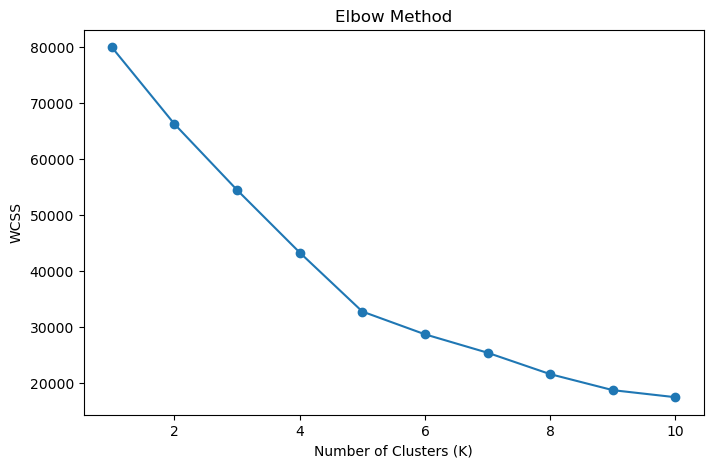

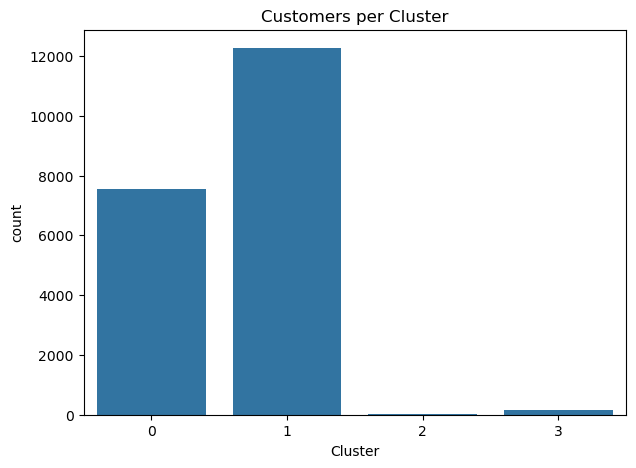

Cluster Summary:
         CustAccountBalance  TransactionAmount (INR)    Age   Hour
Cluster                                                           
0                 110427.17                  1281.20  36.55  13.31
1                  97768.89                  1219.04  38.59  19.72
2               18119160.68                  7259.76  35.68  14.89
3                 274548.69                 64438.78  35.15  15.60


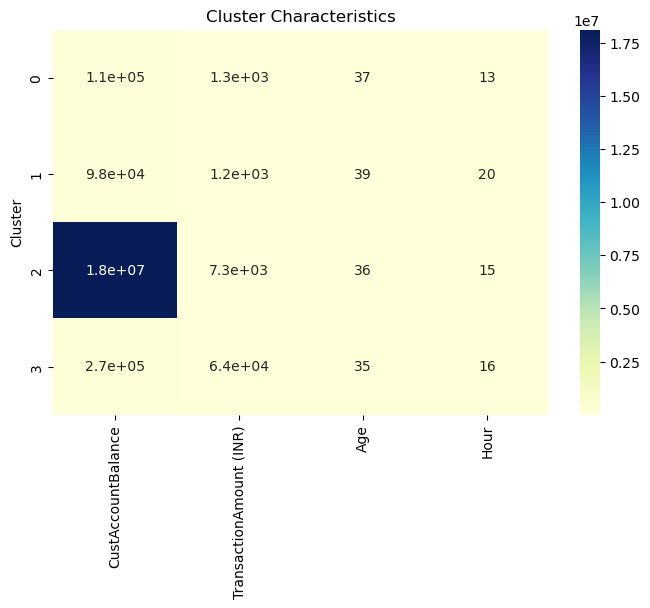

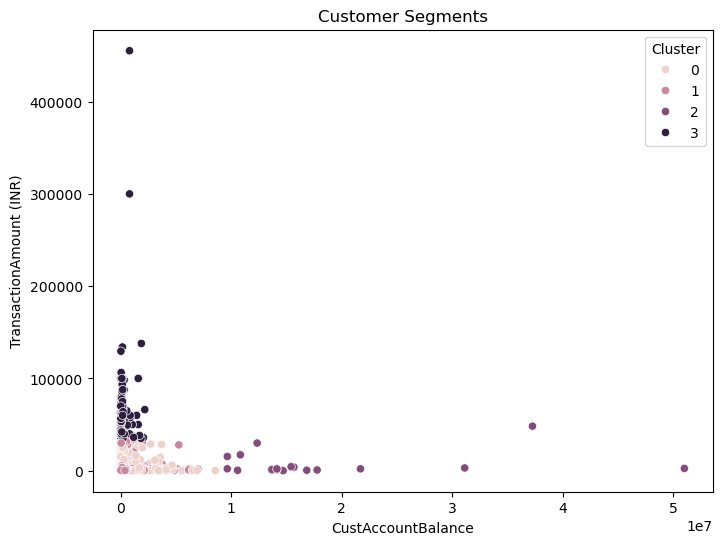

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Selected features
features = [
    'CustAccountBalance',
    'TransactionAmount (INR)',
    'Age',
    'Hour'
]

# Create feature matrix
X = data[features].copy()

# Handle missing values
X = X.fillna(X.median())

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

data['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Distribution
plt.figure(figsize=(7,5))
sns.countplot(data=data, x='Cluster')
plt.title('Customers per Cluster')
plt.show()

# Cluster Summary
cluster_summary = data.groupby('Cluster')[features].mean().round(2)

print("Cluster Summary:")
print(cluster_summary)

# Heatmap for Presentation
plt.figure(figsize=(8,5))
sns.heatmap(
    cluster_summary,
    annot=True,
    cmap='YlGnBu'
)
plt.title('Cluster Characteristics')
plt.show()

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x='CustAccountBalance',
    y='TransactionAmount (INR)',
    hue='Cluster'
)
plt.title('Customer Segments')
plt.show()